# Capacity-adequacy diagnostics for Run A vs Run B (BESS technology-inclusion counterfactual)

Tests two candidate adequacy metrics built on PyPSA's `n.statistics` accessor, ported from
the reserve-margin definition used in a comparable Indonesia power-system thesis
(regional reserve margin = (firm + credited-variable capacity - peak demand) / peak demand).

**Two candidates are tested, not one** -- see the conclusion cell for which one actually
fits this thesis's model structure and why.

1. `reserve_margin_analog()` -- direct port of the Indonesia-thesis formula. Requires an
   *assumed* capacity-credit input for solar/wind (needs a cited source per technology;
   Senegal-specific ELCC studies do not currently exist in this bibliography).
2. `capacity_credit_of_bess()` -- World Bank Group (2020, paras 45-49) approach: capacity
   credit as a model *output*, read off the change in firm/dispatchable capacity the
   optimiser builds in Run A vs Run B. No assumed input required; this is the approach
   the World Bank report explicitly recommends over assumption-based capacity credits,
   and it maps directly onto this thesis's existing technology-inclusion counterfactual.

Both are validated end-to-end against a synthetic single-node Senegal-style network
before being pointed at real network files, following standard practice for this thesis's
notebooks.

## 1. Synthetic network builder (Run A / Run B)

In [1]:
"""
Synthetic PyPSA network mimicking a simplified Senegal-style system:
- one bus, one year, hourly snapshots (small slice for speed)
- OCGT + existing oil thermal = dispatchable/'firm' fleet
- Solar PV + wind = variable renewable fleet
- Battery storage, capacity NOT built in "Run A", endogenous in "Run B"
This mirrors the technology-inclusion counterfactual described in the thesis:
Run A excludes BESS as investable, Run B lets PyPSA size power/energy/duration.
"""
import pypsa
import numpy as np
import pandas as pd

def build_network(include_bess: bool, seed: int = 0) -> pypsa.Network:
    rng = np.random.default_rng(seed)
    n = pypsa.Network()
    hours = pd.date_range("2030-01-01", periods=24*7, freq="h")
    n.set_snapshots(hours)

    n.add("Bus", "senegal")

    # crude synthetic demand profile: evening peak, weekday/weekend shape
    t = np.arange(len(hours))
    hour_of_day = hours.hour.values
    base = 800 + 150 * np.sin(2 * np.pi * (hour_of_day - 6) / 24)
    evening_peak = 250 * np.exp(-0.5 * ((hour_of_day - 20) / 2.5) ** 2)
    demand = base + evening_peak + rng.normal(0, 15, size=len(hours))
    demand = np.clip(demand, 400, None)
    n.add("Load", "load", bus="senegal", p_set=demand)

    # existing dispatchable / firm thermal fleet (fixed, not extendable)
    n.add("Generator", "OCGT_existing", bus="senegal", carrier="OCGT",
          p_nom=450, p_nom_extendable=False, marginal_cost=180)
    n.add("Generator", "Oil_existing", bus="senegal", carrier="oil",
          p_nom=300, p_nom_extendable=False, marginal_cost=220)

    # extendable firm capacity (so the model can add more OCGT if it needs firm MW)
    n.add("Generator", "OCGT_new", bus="senegal", carrier="OCGT",
          p_nom=0, p_nom_extendable=True, capital_cost=60000, marginal_cost=180)

    # variable renewables with synthetic capacity factor profiles
    hours_frac = t / len(t)
    solar_cf = np.clip(np.sin(np.pi * (hour_of_day - 6) / 12), 0, 1)
    solar_cf = np.where((hour_of_day >= 6) & (hour_of_day <= 18), solar_cf, 0)
    wind_cf = 0.35 + 0.25 * np.sin(2 * np.pi * t / (24 * 3)) + rng.normal(0, 0.05, len(t))
    wind_cf = np.clip(wind_cf, 0.02, 0.9)

    n.add("Generator", "Solar_existing", bus="senegal", carrier="solar",
          p_nom=200, p_nom_extendable=False, p_max_pu=solar_cf, marginal_cost=0)
    n.add("Generator", "Solar_new", bus="senegal", carrier="solar",
          p_nom=0, p_nom_extendable=True, p_max_pu=solar_cf,
          capital_cost=25000, marginal_cost=0)
    n.add("Generator", "Wind_new", bus="senegal", carrier="wind",
          p_nom=0, p_nom_extendable=True, p_max_pu=wind_cf,
          capital_cost=35000, marginal_cost=0)

    # unserved energy / VoLL slack, consistent with the thesis's two-VoLL-uses distinction
    n.add("Generator", "load_shedding", bus="senegal", carrier="load_shedding",
          p_nom=1e5, marginal_cost=5000)

    if include_bess:
        n.add("StorageUnit", "BESS", bus="senegal", carrier="battery",
              p_nom=0, p_nom_extendable=True,
              max_hours=4,  # will be swept separately if duration is also a decision var
              capital_cost=45000, marginal_cost=1,
              efficiency_store=0.95, efficiency_dispatch=0.95,
              cyclic_state_of_charge=True)

    return n



## 2. Capacity-split functions built on `n.statistics`

In [2]:
"""
Reserve-margin-analog and empirical-capacity-credit functions built on
PyPSA's n.statistics accessor, for comparing Run A (BESS excluded) vs
Run B (BESS endogenous) in the Senegal BESS thesis.

Two distinct outputs are produced, matching two different literature
traditions cited in the thesis:

1. reserve_margin_analog(): an input-assumption style reserve margin,
   analogous to the de Weijer/Indonesia-thesis definition
   RM = (firm + credited_variable - peak) / peak * 100,
   using assumed capacity-credit factors for solar/wind (needs a cited
   source per technology -- this is the same caveat the World Bank 2020
   BESS report flags in its capacity-credit discussion).

2. capacity_credit_of_bess(): the World Bank Group (2020, paras 45-49)
   recommended approach -- run the capacity expansion model with and
   without BESS as an investable technology and read the *change* in
   firm (dispatchable/thermal) capacity the optimiser chooses to build.
   This treats capacity credit as a model OUTPUT rather than an assumed
   INPUT, which is exactly the Run A vs Run B counterfactual already
   defined in this thesis.
"""
import pandas as pd

# n.statistics.optimal_capacity() reports different physical quantities
# depending on component type: Generator/Link/StorageUnit report POWER
# (p_nom_opt, MW), but Store reports ENERGY (e_nom_opt, MWh). PyPSA-Earth's
# real networks split BESS across exactly these types -- existing capacity
# as StorageUnit (MW), new/endogenous capacity as Store (MWh) + charger/
# discharger Link (MW) -- and both halves can share the identical carrier
# string "battery". Naively grouping n.statistics.optimal_capacity() by
# carrier alone therefore sums MW and MWh together under one label. Verified
# against baseline_bess_2030_overnight: StorageUnit battery = 89 MW,
# Store battery = 0.0046 MWh, silently summed to a meaningless "89.0046".
_POWER_COMPONENTS = ("Generator", "Link", "StorageUnit")


def _capacity_by_carrier(n):
    """
    Optimal POWER capacity per carrier, MW. Restricted to component types
    whose optimal_capacity is actually a power quantity (Generator, Link,
    StorageUnit p_nom_opt) -- Store is deliberately excluded here, since
    its optimal_capacity is energy (e_nom_opt, MWh) and isn't comparable to
    MW firm-capacity/peak-demand figures. Use battery_power_capacity_mw()
    below if you need the BESS side specifically, since that also needs to
    fold in the charger Link's MW rather than the Store's MWh.
    """
    cap = n.statistics.optimal_capacity(groupby="carrier")
    cap = cap[cap.index.get_level_values("component").isin(_POWER_COMPONENTS)]
    return cap.groupby(level="carrier").sum()


def _battery_power_capacity_mw(n, storageunit_carrier="battery", charger_carrier="battery charger"):
    """
    Total BESS POWER capacity (MW), combining existing capacity (modelled
    as StorageUnit, p_nom_opt) with new/endogenous capacity (modelled as
    Store + charger/discharger Link, where the charger Link's p_nom_opt is
    the power-side figure -- NOT the Store's e_nom_opt, which is energy).
    Same StorageUnit/Store split as extract_bess_combined() in the
    dispatchable-solar-LCOS notebook; see that notebook for the full
    energy-capacity + dispatch treatment if you need MWh/throughput instead
    of MW here.
    """
    cap = n.statistics.optimal_capacity(groupby="carrier")
    su_mw = cap.get(("StorageUnit", storageunit_carrier), 0.0)
    charger_mw = cap.get(("Link", charger_carrier), 0.0)
    return su_mw + charger_mw


def _peak_demand_mw(n):
    return n.loads_t.p_set.sum(axis=1).max()


def reserve_margin_analog(n, firm_carriers, variable_capacity_credits,
                           exclude_carriers=("load_shedding", "load shedding")):
    """
    Parameters
    ----------
    n : pypsa.Network (solved)
    firm_carriers : list[str]
        Carriers counted at full optimal capacity (dispatchable thermal,
        firm imports, hydro with storage if treated as firm).
    variable_capacity_credits : dict[str, float]
        e.g. {"solar": 0.22, "wind": 0.36} -- MUST be cited assumptions,
        not defaults. Aji et al. (2026)/IRENA (2020)-style ELCC studies
        are the appropriate source; there is no ready-made Senegal value
        in the current bibliography, so this is a placeholder to replace.
    exclude_carriers : iterable[str]
        Carriers to drop before totalling (slack/load-shedding generator).
    """
    cap = _capacity_by_carrier(n).drop(labels=list(exclude_carriers),
                                        errors="ignore")
    firm_mw = cap.reindex(firm_carriers).fillna(0).sum()
    credited_mw = sum(
        cap.get(carrier, 0.0) * credit
        for carrier, credit in variable_capacity_credits.items()
    )
    peak_mw = _peak_demand_mw(n)
    reserve_margin_pct = (firm_mw + credited_mw - peak_mw) / peak_mw * 100
    return {
        "firm_capacity_MW": firm_mw,
        "credited_variable_capacity_MW": credited_mw,
        "peak_demand_MW": peak_mw,
        "reserve_margin_pct": reserve_margin_pct,
    }


def capacity_credit_of_bess(n_without_bess, n_with_bess, firm_carriers,
                             exclude_carriers=("load_shedding", "load shedding")):
    """
    Empirical (output-based) capacity credit of BESS, following
    World Bank Group (2020, paras 45-49): compare the firm/dispatchable
    capacity the optimiser builds in Run A vs Run B, at the same
    reliability standard (same VoLL / unserved-energy tolerance).

    Returns the avoided/displaced firm capacity in MW and, if BESS
    power capacity is available in Run B, the implied capacity-credit
    ratio (avoided firm MW / installed BESS power MW). BESS power capacity
    uses _battery_power_capacity_mw() (StorageUnit + charger Link), not a
    naive carrier lookup, so it's correct whether Run B's BESS is a single
    StorageUnit (synthetic demo) or a mixed StorageUnit+Store/Link fleet
    (real PyPSA-Earth networks).
    """
    cap_a = _capacity_by_carrier(n_without_bess).drop(
        labels=list(exclude_carriers), errors="ignore")
    cap_b = _capacity_by_carrier(n_with_bess).drop(
        labels=list(exclude_carriers), errors="ignore")

    firm_a = cap_a.reindex(firm_carriers).fillna(0).sum()
    firm_b = cap_b.reindex(firm_carriers).fillna(0).sum()
    displaced_firm_mw = firm_a - firm_b

    bess_power_mw = _battery_power_capacity_mw(n_with_bess)
    implied_credit = (displaced_firm_mw / bess_power_mw
                       if bess_power_mw > 0 else float("nan"))

    return {
        "firm_capacity_run_A_MW": firm_a,
        "firm_capacity_run_B_MW": firm_b,
        "displaced_firm_capacity_MW": displaced_firm_mw,
        "bess_power_capacity_run_B_MW": bess_power_mw,
        "implied_bess_capacity_credit": implied_credit,
    }


## 3. Solve Run A and Run B on the synthetic network

In [3]:
import logging
logging.getLogger("pypsa").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

n_a = build_network(include_bess=False, seed=1)
n_a.optimize(solver_name="highs", solver_options={"output_flag": False})

n_b = build_network(include_bess=True, seed=1)
n_b.optimize(solver_name="highs", solver_options={"output_flag": False})

print("Run A objective:", round(n_a.objective, 1))
print("Run B objective:", round(n_b.objective, 1))

Run A objective: 39153210.9
Run B objective: 38310564.2


## 4. Option 1 -- reserve margin analog (assumption-based)

Set your firm carriers and cited capacity-credit values here. The 0.22 / 0.36 below are
placeholders copied from the Indonesia thesis appendix (their Table A.13) purely to show
the mechanics -- **do not cite these for Senegal**. If you want this metric, the credit
factors need a Senegal- or West-Africa-specific source (e.g. an ELCC-style calculation,
or IRENA (2020) methodology applied to Senegal's own peak-coincident solar/wind profile).

In [4]:
firm_carriers = ["OCGT", "oil"]
placeholder_credits = {"solar": 0.22, "wind": 0.36}  # NEEDS a Senegal-specific citation

print("Run A:")
for k, v in reserve_margin_analog(n_a, firm_carriers, placeholder_credits).items():
    print(f"  {k}: {v:.2f}")

print("\nRun B:")
for k, v in reserve_margin_analog(n_b, firm_carriers, placeholder_credits).items():
    print(f"  {k}: {v:.2f}")

Run A:
  firm_capacity_MW: 974.77
  credited_variable_capacity_MW: 50.23
  peak_demand_MW: 1003.35
  reserve_margin_pct: 2.16

Run B:
  firm_capacity_MW: 867.50
  credited_variable_capacity_MW: 45.82
  peak_demand_MW: 1003.35
  reserve_margin_pct: -8.97


## 5. Option 2 -- empirical capacity credit of BESS (World Bank Group 2020 approach)

No assumed capacity-credit input. Reads the *displaced firm capacity* directly off what
the optimiser builds in Run A vs Run B, at the same VoLL/reliability standard.

In [5]:
for k, v in capacity_credit_of_bess(n_a, n_b, firm_carriers).items():
    print(f"{k}: {v:.2f}")

firm_capacity_run_A_MW: 974.77
firm_capacity_run_B_MW: 867.50
displaced_firm_capacity_MW: 107.27
bess_power_capacity_run_B_MW: 116.33
implied_bess_capacity_credit: 0.92


## 6. Which one actually fits this thesis?

**Option 2, not Option 1.** Three reasons:

1. **No uncited input needed.** Option 1 requires a solar/wind capacity-credit assumption
   you cannot currently source for Senegal without doing a separate ELCC study -- exactly
   the kind of unjustified input assumption the CBA framework chapter is set up to avoid
   (Section 5.5, avoiding double counting; the same World Bank 2020 report you're already
   citing explicitly flags this as poor practice in paras 43-45 of its capacity-credit
   discussion).

2. **It maps onto value streams you already report.** Displaced/avoided thermal capacity
   is literally the "generation capacity deferral" benefit category in Denholm et al.
   (2013) and IRENA (2020) -- the same benefit taxonomy your CBA framework (Chapter 5) is
   built on. Option 2 is not a new metric competing with NPV/BCR/EIRR; it is the technical
   quantity that sits behind one line of your benefit-side decomposition (Section 7.4.1),
   letting you report it in MW alongside its monetised value.

3. **Option 1's output is not meaningful in your model as currently structured.** Notice
   the reserve margin analog went *negative* in Run B above. That is not a Senegal-specific
   finding, it is a structural feature: your model (like the Indonesia thesis's Calliope
   setup) does not optimise against an explicit reserve-margin target or provincial
   capacity-target constraint -- it minimises system cost subject to a VoLL-penalised
   slack generator. A reserve-margin threshold was a planning constraint baked into their
   model; it is not one in yours. Reporting Option 1's number without that constraint
   existing in the model would misrepresent what the model is actually doing.

**Recommended framing for Chapter 7:** report displaced firm capacity (MW) and the implied
capacity credit ratio as a technical exhibit under Section 7.3.4 (Headline technical
impact) or 7.4.1 (Benefit-side decomposition), stated explicitly as "capacity credit
revealed by the model" per World Bank Group (2020), not as a reserve-margin percentage.

## 7. Next steps to point this at your real networks

Replace the synthetic network calls with your actual solved networks, e.g.:

```python
import pypsa
n_a = pypsa.Network("/Users/william/thesis/pypsa-earth/results/run_a_no_bess.nc")
n_b = pypsa.Network("/Users/william/thesis/pypsa-earth/results/run_b_with_bess.nc")
```

Then:
- Update `firm_carriers` to match your actual carrier names (check with
  `n_a.generators.carrier.unique()`).
- If you have multiple snapshots/periods (multi-year), decide whether you want capacity
  credit per period or for a single target year -- `_capacity_by_carrier()` currently
  reads `n.statistics.optimal_capacity()`, which already handles multi-period networks
  correctly (this is the same accessor you used to fix the system-cost undercounting
  issue, so the multi-period behaviour is already validated in your workflow).
- If BESS duration is also a decision variable rather than fixed at `max_hours=4`, pull
  the optimised duration from `n_b.storage_units.loc["BESS", "max_hours"]` (or per-node if
  BESS siting is endogenous) and report it alongside the capacity-credit ratio, since a
  1-hour battery and an 8-hour battery earning the same "implied capacity credit" number
  would mean very different things physically.

## 8. All `overnight` years, on the real solved networks

Run A = `results/baseline_no_bess_{year}_overnight/`, Run B =
`results/baseline_bess_{year}_overnight/` (electricity-only pipeline,
`networks/elec_s_24_ec_lv1.0_1h.nc`), for every year both sides have a
solved result: 2030, 2035, 2040, 2045, 2050.

Only **Option 2** (`capacity_credit_of_bess`) is looped here, not Option 1.
That's not a shortcut -- looping years doesn't fix Option 1's actual
blocker, which is the missing Senegal-specific solar/wind capacity-credit
citation flagged in section 4. Section 6's conclusion (Option 2 is the one
that fits this thesis's model structure) still holds on the real networks.

`firm_carriers` is updated from the synthetic demo's `["OCGT", "oil"]` to
what's actually present in these networks: `["OCGT", "CCGT", "coal", "oil",
"hydro"]`. Hydro is included -- it's modelled as a `StorageUnit`
(reservoir-style, controllable), not a plain variable-output generator, so
it belongs on the firm/dispatchable side, not lumped with solar/onwind.
Verify this matches how you're treating hydro elsewhere in the thesis
before relying on it (e.g. if any of it is actually run-of-river with no
real dispatchability, it arguably shouldn't count as fully firm).

In [6]:
import glob
import re
from pathlib import Path
import pypsa

RESULTS_DIR = Path("/Users/william/thesis/pypsa-earth/results")
firm_carriers_real = ["OCGT", "CCGT", "coal", "oil", "hydro"]

no_bess_paths = sorted(glob.glob(
    str(RESULTS_DIR / "baseline_no_bess_*_overnight" / "networks" / "elec_s_24_ec_lv1.0_1h.nc")
))

rows = []
for p_a in no_bess_paths:
    m = re.search(r"baseline_no_bess_(\d{4})_overnight", p_a)
    year = m.group(1)
    p_b = RESULTS_DIR / f"baseline_bess_{year}_overnight" / "networks" / "elec_s_24_ec_lv1.0_1h.nc"
    if not p_b.exists():
        print(f"{year}: skipping, no matching baseline_bess run at {p_b}")
        continue

    n_a = pypsa.Network(p_a)
    n_b = pypsa.Network(str(p_b))
    result = capacity_credit_of_bess(n_a, n_b, firm_carriers_real)
    rows.append({"year": int(year), **result})

capacity_credit_summary = pd.DataFrame(rows).set_index("year").sort_index()
capacity_credit_summary

,firm_capacity_run_A_MW,firm_capacity_run_B_MW,displaced_firm_capacity_MW,bess_power_capacity_run_B_MW,implied_bess_capacity_credit
year,,,,,
2030,1620.96051,1620.96016,0.00035,89.00179,0.000004
2035,1620.96000,1620.96056,-0.00056,93.48849,-0.000006
2040,1634.16307,1620.96068,13.20239,338.55144,0.038997
2045,1996.07950,1620.96015,375.11935,913.70281,0.410549
2050,2313.71458,1518.46286,795.25172,2704.70981,0.294025


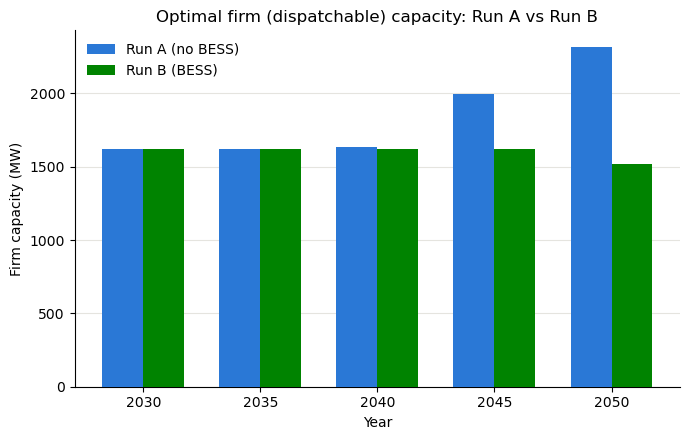

In [7]:
import matplotlib.pyplot as plt
import numpy as np

years = capacity_credit_summary.index.astype(str)
x = np.arange(len(years))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width / 2, capacity_credit_summary["firm_capacity_run_A_MW"], width,
       color="#2a78d6", label="Run A (no BESS)", zorder=3)
ax.bar(x + width / 2, capacity_credit_summary["firm_capacity_run_B_MW"], width,
       color="#008300", label="Run B (BESS)", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel("Year")
ax.set_ylabel("Firm capacity (MW)")
ax.set_title("Optimal firm (dispatchable) capacity: Run A vs Run B")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4df", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

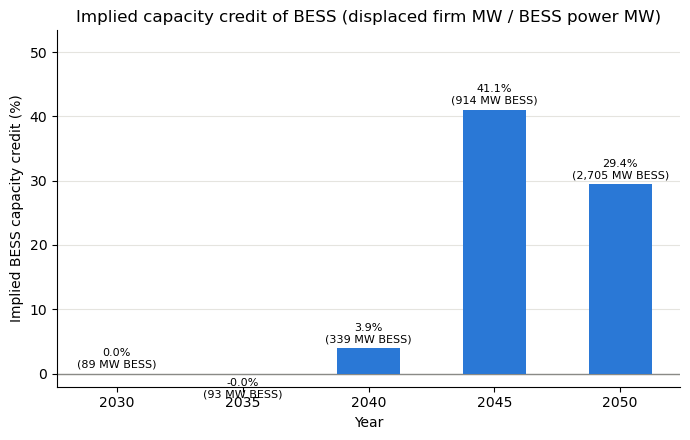

In [8]:
credit_pct = capacity_credit_summary["implied_bess_capacity_credit"] * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(x, credit_pct, width=0.5, color="#2a78d6", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_xlabel("Year")
ax.set_ylabel("Implied BESS capacity credit (%)")
ax.set_title("Implied capacity credit of BESS (displaced firm MW / BESS power MW)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4df", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.axhline(0, color="#8a8a86", linewidth=1)
ax.set_ylim(top=credit_pct.max() * 1.3)

for bar, pct, bess_mw in zip(bars, credit_pct, capacity_credit_summary["bess_power_capacity_run_B_MW"]):
    va = "bottom" if pct >= 0 else "top"
    offset = 3 if pct >= 0 else -3
    ax.annotate(f"{pct:.1f}%\n({bess_mw:,.0f} MW BESS)", (bar.get_x() + bar.get_width() / 2, pct),
                xytext=(0, offset), textcoords="offset points", ha="center", va=va, fontsize=8)

plt.tight_layout()
plt.show()